# Yeni Kavramlar

## Type Hint Nedir?

Type hint, bir değişkenin veya fonksiyon parametresinin hangi veri tipinde olması beklendiğini belirtmek için kullanılır.

Örnek:

```python
keywords: list[str]
```

Bu ifade:

> `keywords` değişkeninin bir liste olması ve listenin içinde string değerler bulunması bekleniyor.

anlamına gelir.

Örnek geçerli değer:

```python
["Python", "Java", "C++"]
```

Başka bir örnek:

```python
geo: str = "TR"
```

Bu ifade:

* `geo` parametresinin string olması beklendiğini
* varsayılan değerinin `"TR"` olduğunu

gösterir.

Type hint kullanmak zorunlu değildir ancak:

* kodun okunabilirliğini artırır,
* Pylance gibi araçların daha iyi öneri vermesini sağlar,
* yanlış tip kullanımını daha erken fark etmeye yardımcı olur.

---

## Return Type Hint

Fonksiyonun sonunda hangi veri tipinin döndürülmesi beklendiği de belirtilebilir.

Örnek:

```python
def fetch_trends_data(...) -> pd.DataFrame:
```

Buradaki:

```python
-> pd.DataFrame
```

ifadesi:

> Bu fonksiyonun bir Pandas DataFrame döndürmesi bekleniyor.

anlamına gelir.

---

## Docstring Nedir?

Docstring, bir fonksiyonun ne yaptığını açıklayan metindir.

Örnek:

```python
def fetch_trends_data(...):
    """Google Trends'ten zaman serisi ilgi verisi çeker."""
```

Docstring'in amacı:

* fonksiyonun görevini açıklamak,
* kodu okuyan kişinin fonksiyonu daha hızlı anlamasını sağlamak,
* IDE ve `help()` gibi araçların açıklama göstermesine yardımcı olmaktır.

---

## PEP 8 ve Boşluk Kullanımı

PEP 8'e göre atama operatörünün iki tarafında boşluk bırakılır.

Doğru:

```python
pytrend = TrendReq()
```

Yanlış:

```python
pytrend=TrendReq()
```

Benzer şekilde fonksiyon parametrelerinde de okunabilirlik korunmalıdır.

Doğru:

```python
pytrend.build_payload(
    kw_list=keywords,
    timeframe=timeframe,
    geo=geo,
)
```

Tek satıra sıkıştırmak çalışabilir fakat daha az okunaklıdır:

```python
pytrend.build_payload(kw_list=keywords, timeframe=timeframe, geo=geo)
```

---

## Ruff ve Pylance Arasındaki Fark

### Ruff

Ruff daha çok:

* kod formatlama,
* lint kontrolü,
* gereksiz importları bulma,
* PEP 8'e aykırı kodları işaretleme

işlerinde kullanılır.

### Pylance

Pylance ise:

* otomatik kod tamamlama,
* metod önerileri,
* type checking,
* değişken ve fonksiyon tiplerini analiz etme,
* yanlış import veya kullanım hatalarını gösterme

gibi görevlerde kullanılır.

Kısaca:

```text
Ruff    -> Kod stili ve temizlik
Pylance -> Kod zekası ve tip analizi
```

---

## VS Code Interpreter Neden Önemli?

VS Code'un doğru Python sanal ortamını kullanması gerekir.

Örneğin proje ortamı:

```text
cotale-env/bin/python
```

ise VS Code'da:

```text
Python: Select Interpreter
```

ile bu ortam seçilmelidir.

Aksi halde Pylance:

* bazı kütüphaneleri göremeyebilir,
* otomatik tamamlama yapmayabilir,
* `pytrend.` yazıldığında metodları göstermeyebilir.


# Python Modülü ve Import Mantığı

## Module Nedir?

Python'daki bir `.py` dosyası bir **module** olarak kullanılabilir.

Örneğin proje içerisinde:

```text
src/
└── fetch_data.py
```

dosyası bulunuyorsa `fetch_data.py` bir Python modülüdür.

Dosya içerisindeki fonksiyonlar başka dosyalardan import edilerek tekrar kullanılabilir.

---

## Bir Modülden Fonksiyon Import Etmek

Örneğin:

```python
from src.fetch_data import fetch_trends_data
```

ifadesi şu şekilde okunabilir:

```text
src
 ↓
fetch_data.py
 ↓
fetch_trends_data()
```

Yani:

> `src` içindeki `fetch_data.py` modülünden `fetch_trends_data` fonksiyonunu getir.

`.py` uzantısı import sırasında yazılmaz.

---

## Neden Modül Kullanıyoruz?

Notebook içerisinde bütün veri çekme kodunu tekrar tekrar yazmak yerine veri çekme işlemini ayrı bir fonksiyonda tutabiliriz.

Örneğin eskiden:

```python
pytrend = TrendReq(...)
pytrend.build_payload(...)
data = pytrend.interest_over_time()
```

işlemlerini her yerde tekrar etmemiz gerekebilirdi.

Fonksiyonlaştırdıktan sonra:

```python
data = fetch_trends_data(
    keywords=["Python", "Java", "C++"]
)
```

yeterlidir.

Bu yaklaşım:

* kod tekrarını azaltır,
* kodun okunabilirliğini artırır,
* aynı kodun farklı yerlerde kullanılmasını sağlar,
* bakım ve hata düzeltmeyi kolaylaştırır.

---

## Default Parameter Kullanımı

Fonksiyon:

```python
def fetch_trends_data(
    keywords: list[str],
    geo: str = "TR",
    timeframe: str = "today 5-y",
):
```

şeklinde tanımlanmışsa yalnızca `keywords` zorunludur.

Örneğin:

```python
fetch_trends_data(
    keywords=["Python", "Java"]
)
```

çağrısı otomatik olarak:

```text
geo = "TR"
timeframe = "today 5-y"
```

değerlerini kullanır.

İstenirse varsayılan değerler değiştirilebilir:

```python
fetch_trends_data(
    keywords=["Python"],
    geo="US",
    timeframe="today 12-m",
)
```


# Input Validation

Input validation, bir fonksiyona verilen değerlerin işleme başlamadan önce geçerli olup olmadığının kontrol edilmesidir.

Örneğin Google Trends sorgusunda keyword listesinin boş olması anlamlı değildir.

```python
if not keywords:
    raise ValueError("Keyword listesi boş olamaz.")
```

Burada:

```python
if not keywords
```

ifadesi listenin boş olup olmadığını kontrol eder.

Boş liste:

```python
[]
```

Python tarafından `False` olarak değerlendirilir.

Bu nedenle `not keywords` ifadesi `True` olur ve hata oluşturulur.

## ValueError

`ValueError`, verilen değerin tipi uygun olmasına rağmen değerinin geçersiz olduğu durumlarda kullanılabilir.

Örneğin:

```python
keywords=[]
```

bir `list`tir ancak kullanılabilir bir keyword içermediği için geçersizdir.

---

## Type Kontrolü

Listedeki bütün değerlerin string olduğunu kontrol etmek için:

```python
all(isinstance(keyword, str) for keyword in keywords)
```

kullanılabilir.

### isinstance()

Bir değerin belirli bir veri tipine ait olup olmadığını kontrol eder.

Örneğin:

```python
isinstance("Python", str)
```

sonucu:

```text
True
```

olur.

Ancak:

```python
isinstance(15, str)
```

sonucu:

```text
False
```

olur.

### all()

`all()` kendisine verilen bütün koşulların `True` olup olmadığını kontrol eder.

Örneğin:

```python
all([True, True, True])
```

→ `True`

```python
all([True, False, True])
```

→ `False`

Bu nedenle:

```python
all(isinstance(keyword, str) for keyword in keywords)
```

ifadesi listedeki bütün keywordlerin string olup olmadığını kontrol eder.

---

## TypeError

Bir fonksiyona beklenmeyen veri tipi verildiğinde `TypeError` kullanılabilir.

Örneğin:

```python
["Python", 15]
```

listesinde `15` string olmadığı için:

```python
raise TypeError("Tüm keyword değerleri string olmalıdır.")
```

ile hata oluşturulabilir.

Input validation sayesinde hatalı veriler API'ye gönderilmeden önce yakalanabilir.


# Docstring Yapısı: Args, Returns ve Raises

Fonksiyonun hemen altında bulunan üç tırnaklı açıklamaya **docstring** denir.

Örneğin:

```python
def fetch_trends_data(...):
    """Google Trends'ten zaman serisi verisi çeker."""
```

Docstring fonksiyonun içinde, fonksiyon tanımından hemen sonra bulunmalıdır.

Fonksiyonun dışında yazılan:

```python
"""Bir açıklama."""
```

ise o fonksiyonun docstring'i değildir. Bağımsız bir string ifadesidir.

## Args

`Args`, fonksiyonun aldığı parametreleri açıklar.

```text
Args:
    keywords: Aranacak kelimelerin listesi.
    geo: Ülke kodu.
```

## Returns

`Returns`, fonksiyonun geri döndürdüğü değeri açıklar.

```text
Returns:
    Google Trends zaman serisini içeren DataFrame.
```

## Raises

`Raises`, fonksiyonun hangi durumlarda hata oluşturabileceğini açıklar.

```text
Raises:
    ValueError: Keyword listesi boş olduğunda.
    TypeError: Keyword değerlerinden biri string olmadığında.
```

Bu yapı kodun kendisini değiştirmez; kodun nasıl kullanılacağını ve hangi durumlarda ne davranış göstereceğini dokümante eder.


# Python'da Import Cache ve Dosya Değişiklikleri

Bir Python modülü ilk kez import edildiğinde Python modülü çalıştırır ve belleğe yükler.

Örneğin:

```python
from src.fetch_data import fetch_trends_data
```

çalıştırıldığında `fetch_data.py` içerisindeki kod Python oturumuna yüklenir.

Daha sonra `fetch_data.py` dosyası değiştirilse bile aynı Python oturumunda tekrar:

```python
from src.fetch_data import fetch_trends_data
```

yazmak modülü her zaman yeniden çalıştırmaz.

Python daha önce yüklediği modülü bellekte tutabilir.

Bu nedenle geliştirme sırasında kaynak dosyada değişiklik yaptıktan sonra en basit yöntem Python oturumunu kapatıp yeniden açmaktır.

```python
exit()
```

Daha sonra:

```bash
python
```

ile yeni bir Python oturumu başlatılır ve modül yeniden import edilir.

## Neden Böyle Yapılıyor?

Python'un her `import` işleminde aynı modülü tekrar tekrar çalıştırması gereksiz ve yavaş olabilir.

Bu nedenle import edilen modüller bellekte tutulur.

Bu davranışa genel olarak **module caching (modül önbellekleme)** denir.

## Önemli

Kaynak kod değiştirildikten sonra:

```text
Dosyayı kaydet
      ↓
Eski Python oturumunu kapat
      ↓
Yeni Python oturumu aç
      ↓
Modülü yeniden import et
```

şeklinde ilerlemek, geliştirme sırasında eski kodun çalıştırılmasıyla oluşabilecek karışıklıkları önler.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


clean_data = pd.read_csv( # CSV dosyası → DataFrame
    "../data/processed/google_trends_ai_3y_clean.csv", 
    index_col="date", # index columnu date yap
    parse_dates=["date"],
)

Matplotlib is building the font cache; this may take a moment.


pd.read_csv():
CSV dosyasını okuyarak Pandas DataFrame oluşturur.

clean_data =:
Oluşturulan DataFrame'i clean_data değişkenine atar.

index_col="date":
CSV içerisindeki date sütununu DataFrame'in index'i olarak kullanır.

parse_dates=["date"]:
date değerlerinin sıradan string yerine tarih olarak yorumlanmasını
sağlar.

..:
Relative path içerisinde bir üst klasöre çıkmayı ifade eder.

Temel akış:

# Exploratory Data Analysis (EDA)

EDA, **Exploratory Data Analysis** yani keşifsel veri analizi anlamına gelir.

Model kurmadan önce veri setini anlamak için yapılan incelemelerdir.

Amaç doğrudan tahmin yapmak değil, önce verinin nasıl davrandığını
anlamaktır.

Örneğin şu sorular incelenebilir:

- Veri kaç gözlemden oluşuyor?
- Değerlerin genel dağılımı nasıl?
- Hangi trend daha yüksek?
- Zaman içerisinde artış veya düşüş var mı?
- Ani sıçramalar var mı?
- Eksik veya sıra dışı değerler bulunuyor mu?

Genel veri bilimi akışı:

Raw Data
    ↓
Preprocessing
    ↓
Clean Data
    ↓
EDA
    ↓
Modelleme
    ↓
Forecasting

In [2]:
normal_data = pd.read_csv(
    "../data/processed/google_trends_ai_3y_clean.csv"
) # eğer böyle olsaydı

In [3]:
normal_data.head()

,date,chatgpt,gemini,claude
0,2023-07-30,13,1,1
1,2023-08-06,14,1,1
2,2023-08-13,14,1,1
3,2023-08-20,15,1,1
4,2023-08-27,16,1,1


In [4]:
clean_data.head()

,chatgpt,gemini,claude
date,,,
2023-07-30,13,1,1
2023-08-06,14,1,1
2023-08-13,14,1,1
2023-08-20,15,1,1
2023-08-27,16,1,1


In [6]:
normal_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   date     157 non-null    str  
 1   chatgpt  157 non-null    int64
 2   gemini   157 non-null    int64
 3   claude   157 non-null    int64
dtypes: int64(3), str(1)
memory usage: 5.0 KB


In [7]:
clean_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 157 entries, 2023-07-30 to 2026-07-26
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   chatgpt  157 non-null    int64
 1   gemini   157 non-null    int64
 2   claude   157 non-null    int64
dtypes: int64(3)
memory usage: 4.9 KB


In [8]:
type(clean_data.index)

pandas.DatetimeIndex

In [9]:
import matplotlib.pyplot as plt

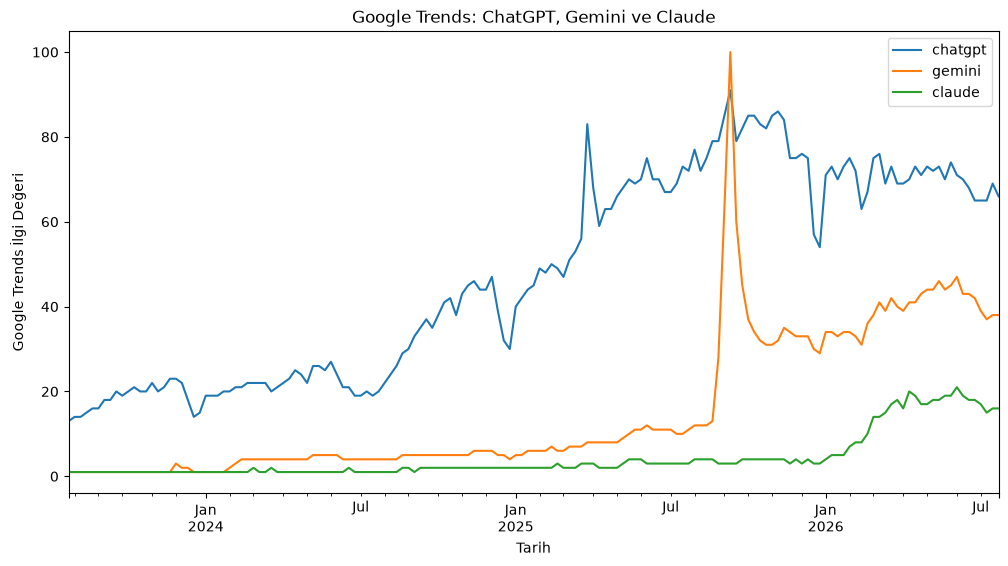

In [10]:
clean_data.plot(
    figsize=(12, 6),
)

plt.title("Google Trends: ChatGPT, Gemini ve Claude")
plt.xlabel("Tarih")
plt.ylabel("Google Trends İlgi Değeri")
plt.show()

clean_data
    ↓
tarihler x ekseni
    ↓
ChatGPT / Gemini / Claude değerleri y ekseni
    ↓
3 ayrı çizgi

figsize=(12, 6) sadece grafiğin boyutu:

12 = genişlik
6  = yükseklik

# İlk Zaman Serisi Gözlemleri

Temiz Google Trends verisi çizgi grafik ile incelendi.

## Trend Nedir?

Trend, zaman serisinin tek tek kısa dönemli hareketlerinden ziyade
uzun vadede gösterdiği genel yönü ifade eder.

Bir seri arada düşüşler yaşasa bile uzun vadede yükseliyorsa
yükselen bir trend gösterebilir.

## İlk Gözlemler

ChatGPT, veri setinin büyük bölümünde diğer iki keyword'e göre daha
yüksek göreli ilgi değerlerine sahiptir.

ChatGPT serisinde uzun vadede belirgin bir yükseliş görülmektedir.

Gemini serisi başlangıçta düşük seviyelerdeyken zaman içerisinde
yükselmiştir. Ayrıca seride kısa süreli ve çok keskin bir yükseliş
bulunmaktadır.

Claude serisi uzun süre düşük seviyelerde seyretmiş, ancak son
dönemde daha belirgin bir yükseliş göstermeye başlamıştır.

## Spike Nedir?

Bir zaman serisinde kısa süre içerisinde oluşan keskin ve geçici
yükselişlere spike denebilir.

Grafikte Gemini değerinin kısa süreli olarak 100'e ulaşması buna
örnektir.

Bir spike'ın grafikte görülmesi nedenini açıklamaz.

Grafik:

- ne olduğunu gösterebilir,
- ancak neden olduğunu tek başına göstermez.

Nedeni araştırmak için ilgili tarih ve dış bilgiler ayrıca
incelenmelidir.

## Google Trends Değerlerinin Yorumu

Google Trends değerleri mutlak arama sayıları değildir.

Değerler 0–100 arasında normalize edilmiş göreli ilgi değerleridir.

Bu nedenle grafikteki 100 değeri "100 arama yapıldı" anlamına gelmez.
Seçilen sorgu, zaman aralığı ve coğrafya içerisindeki en yüksek göreli
ilgi noktasını ifade eder.

In [14]:
spike_date= clean_data["gemini"].idxmax() # maximum değerin index’ini bul.

In [12]:
clean_data["gemini"].max()

np.int64(100)

In [15]:
clean_data.loc[spike_date] # o tarihte üçünün değerini birden gösterecek.

chatgpt     91
gemini     100
claude       3
Name: 2025-09-14 00:00:00, dtype: int64

In [16]:
clean_data.describe()

,chatgpt,gemini,claude
count,157.000000,157.000000,157.000000
mean,47.898089,15.598726,4.382166
std,24.164815,17.379571,5.476681
min,13.000000,1.000000,1.000000
25%,22.000000,4.000000,1.000000
50%,47.000000,6.000000,2.000000
75%,70.000000,33.000000,4.000000
max,91.000000,100.000000,21.000000


# Moving Average / Hareketli Ortalama

Zaman serilerinde haftadan haftaya oluşan küçük dalgalanmalar,
uzun dönemli trendi görmeyi zorlaştırabilir.

Bu dalgalanmaları yumuşatmak için hareketli ortalama kullanılabilir.

```python
rolling_mean = clean_data.rolling(window=4).mean()

In [ ]:
rolling_mean = clean_data.rolling(window=4).mean() # her 4 haftanın ortalamasını alıyor, çizdiğimizde trendi daha iyi görüyoruz, yumuşak görüyoz

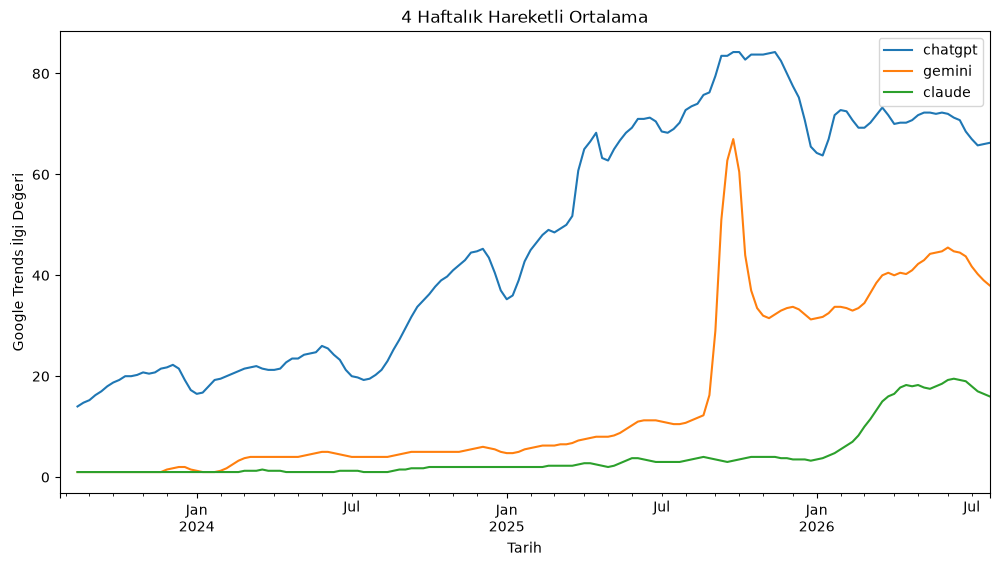

In [18]:
rolling_mean.plot(
    figsize=(12, 6),
)

plt.title("4 Haftalık Hareketli Ortalama")
plt.xlabel("Tarih")
plt.ylabel("Google Trends İlgi Değeri")
plt.show()

In [19]:
monthly_data = clean_data.resample("MS").mean() 

* Buradaki yeni şey resample(). Zaman serisinin zaman aralığını değiştirmek için kullanılıyor.

* "MS" = Month Start, yani aylık gruplar oluştur ve tarihi ayın başlangıcı olarak göster:

In [20]:
monthly_data.head()

,chatgpt,gemini,claude
date,,,
2023-07-01,13.00,1.0,1.0
2023-08-01,14.75,1.0,1.0
2023-09-01,18.00,1.0,1.0
2023-10-01,20.00,1.0,1.0
2023-11-01,21.50,1.0,1.0


In [21]:
monthly_data.loc["2025-08-01":"2025-11-01"]

,chatgpt,gemini,claude
date,,,
2025-08-01,76.40,15.4,3.80
2025-09-01,84.25,67.0,3.25
2025-10-01,83.75,33.5,4.00
2025-11-01,81.00,33.0,3.80


In [22]:
monthly_normalized = (
    monthly_data / monthly_data.to_numpy().max() * 100
)

monthly_data'daki bütün değerler
        ↓
tablodaki en büyük değere böl
        ↓
0–1 aralığına yaklaş
        ↓
100 ile çarp
        ↓
en büyük değer = 100

amaç google trendsin web sitesindeki tablosuyla yaklaştırmaya çalışmak

In [23]:
monthly_normalized.round(0)

,chatgpt,gemini,claude
date,,,
2023-07-01,15.0,1.0,1.0
2023-08-01,18.0,1.0,1.0
2023-09-01,21.0,1.0,1.0
2023-10-01,24.0,1.0,1.0
2023-11-01,26.0,1.0,1.0
2023-12-01,22.0,2.0,1.0
2024-01-01,23.0,1.0,1.0
2024-02-01,25.0,4.0,1.0
2024-03-01,25.0,5.0,2.0


Sonra daha okunaklı görmek için:

monthly_normalized.round(0)

# Haftalık Veriyi Aylık Veriye Dönüştürmek

Pytrends verisi haftalık, Google Trends web arayüzünden indirilen veri ise
aylık olabilir.

İki kaynağı daha anlamlı karşılaştırabilmek için haftalık veri aylık
seviyeye dönüştürülebilir.

## `resample()`

Pandas'ta zaman serisinin zaman çözünürlüğünü değiştirmek için
`resample()` kullanılabilir.

```python
monthly_data = clean_data.resample("MS").mean()

# Önemli Uyarı

Pytrends'in haftalık değerlerini aylık ortalamaya çevirmek ile Google'ın
doğrudan oluşturduğu aylık Google Trends verisi tamamen aynı işlem değildir.

Google Trends aylık veriyi kendi temel arama verilerinden oluşturur ve
0–100 ölçeğini yeniden hesaplayabilir.

Bu nedenle aylıklaştırılmış pytrends verisinin resmi Google Trends
değerleriyle birebir aynı olması beklenmemelidir.

Ama genel trendlerin, yükselişlerin ve düşüşlerin benzer olup olmadığını
kontrol etmek için kullanılabilir.